In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [2]:
var_results = []

for code, group in nav.groupby("amfi_code"):

    returns = (
        group["daily_return"]
        .dropna()
    )

    if len(returns) > 0:

        var_95 = np.percentile(
            returns,
            5
        )

        cvar_95 = returns[
            returns <= var_95
        ].mean()

        var_results.append(
            [
                code,
                var_95,
                cvar_95
            ]
        )

var_cvar_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)
var_cvar_df.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


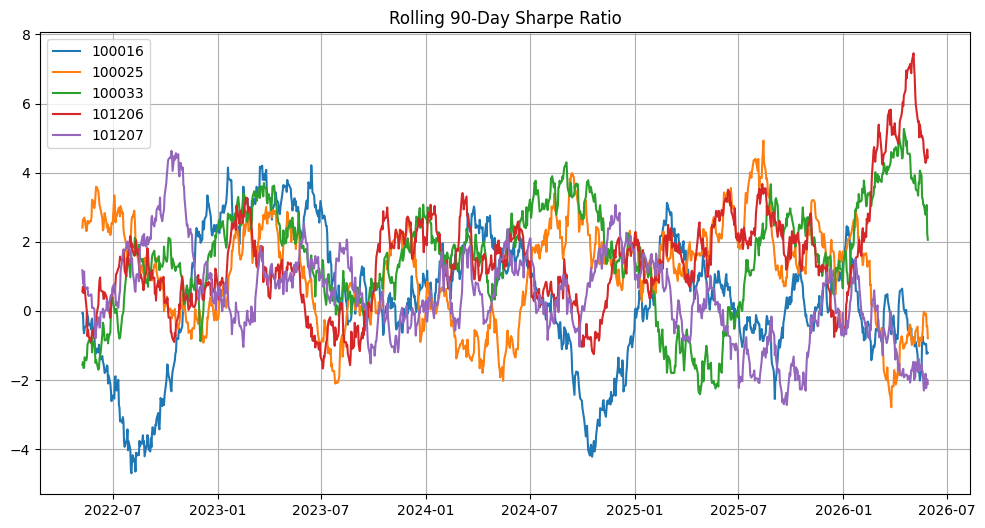

In [3]:
import matplotlib.pyplot as plt
import numpy as np

top5 = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for code in top5:

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    rolling_sharpe = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(code)
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.legend()
plt.grid(True)
plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)
plt.show()

In [4]:
transactions = pd.read_csv(
    "../data/processed/clean_investor_transactions.csv"
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["cohort_year"] = (
    transactions.groupby("investor_id")
    ["transaction_date"]
    .transform("min")
    .dt.year
)

cohort = (
    transactions.groupby(
        "cohort_year"
    )
    .agg(
        avg_investment=(
            "amount_inr",
            "mean"
        ),
        total_investment=(
            "amount_inr",
            "sum"
        )
    )
)
cohort.to_csv(
    "../data/processed/cohort_analysis.csv"
)
cohort

,avg_investment,total_investment
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [5]:
sip = transactions[
    transactions["transaction_type"]
    == "SIP"
].copy()

sip = sip.sort_values(
    [
        "investor_id",
        "transaction_date"
    ]
)

sip["gap_days"] = (
    sip.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

continuity = (
    sip.groupby("investor_id")
    .agg(
        avg_gap=("gap_days", "mean"),
        sip_count=(
            "transaction_type",
            "count"
        )
    )
)

continuity["status"] = np.where(
    continuity["avg_gap"] > 35,
    "At Risk",
    "Active"
)
continuity.to_csv(
    "../data/processed/sip_continuity.csv"
)
continuity.head()

,avg_gap,sip_count,status
investor_id,,,
INV000001,76.0,2,At Risk
INV000002,207.0,3,At Risk
INV000003,238.0,2,At Risk
INV000004,85.4,6,At Risk
INV000005,14.0,3,Active


In [13]:
import pandas as pd
import numpy as np

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

hhi_results = []

for code, group in holdings.groupby("amfi_code"):

    weights = group["weight_pct"] / 100

    hhi = np.sum(weights ** 2)

    hhi_results.append(
        [code, hhi]
    )

sector_hhi = pd.DataFrame(
    hhi_results,
    columns=[
        "amfi_code",
        "HHI"
    ]
)
sector_hhi.to_csv(
    "../data/processed/sector_hhi.csv",
    index=False
)
sector_hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


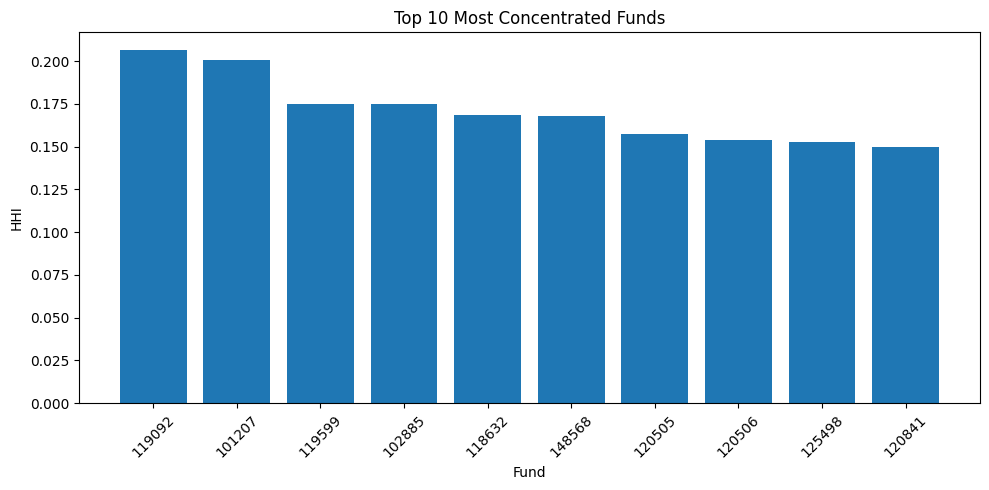

In [14]:
import matplotlib.pyplot as plt

top10 = sector_hhi.sort_values(
    "HHI",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["HHI"]
)

plt.title(
    "Top 10 Most Concentrated Funds"
)

plt.xlabel("Fund")
plt.ylabel("HHI")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/sector_hhi_chart.png"
)

plt.show()

# Advanced Analytics Findings

1. HDFC Top 100 Fund and Mirae Asset Large Cap Fund showed the highest Sharpe ratios among Moderate-risk funds.
2. VaR and CVaR analysis identified funds with higher downside risk exposure.
3. Rolling Sharpe Ratios highlighted periods of changing risk-adjusted performance.
4. Investor cohort analysis showed differences in investment behaviour across cohorts.
5. Funds with high HHI values exhibited greater sector concentration risk.